In [1]:
import csv
import json
import tiktoken


# Data preperation

In [3]:
# First convert csv file to json

SA_file = "/content/SESA-CSD_Train.csv"
SA_json_file = "/content/SESA-CSD_Train.json"

data = []

with open(SA_file, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        # Each row becomes a JSON object
        data.append({
            "instruction":"Analyze the sentimnet in the given sentence. Choose one word from positive,negative, and neutral",
            "input": row["\ufeffData"],
            "output": row["Sentiment"]
        })

# Save as JSON file
with open(SA_json_file, "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

In [4]:
# Open the file and check it
json_file = "/content/SESA-CSD_Train.json"

with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# print first 5 lines
for i, item in enumerate(data[:5]):
    print(f"Item {i+1}:")
    print(item)
    print("-" * 40)
print("Number of items in JSON:", len(data))

Item 1:
{'instruction': 'Analyze the sentimnet in the given sentence. Choose one word from positive,negative, and neutral', 'input': '. الجو اليوم so nice ما شاء الله', 'output': 'Positive'}
----------------------------------------
Item 2:
{'instruction': 'Analyze the sentimnet in the given sentence. Choose one word from positive,negative, and neutral', 'input': 'يا جماعة ، لا تنسون إنه عندنا meeting بكرة !', 'output': 'Neutral'}
----------------------------------------
Item 3:
{'instruction': 'Analyze the sentimnet in the given sentence. Choose one word from positive,negative, and neutral', 'input': ' والله today كان يوم hectic ، والشغل كان مرره overwhelming.', 'output': 'Negative'}
----------------------------------------
Item 4:
{'instruction': 'Analyze the sentimnet in the given sentence. Choose one word from positive,negative, and neutral', 'input': '.هلا ، how are you doing اليوم ؟', 'output': 'Neutral'}
----------------------------------------
Item 5:
{'instruction': 'Analyze th

In [5]:
def format_input(entry):
    instruction_text = (
       # f".في الأسفل تعليمة تصف المهمة المطلوبة"
       # f".أكتب رد مناسب يجيب على المطلوب"
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    # Check if 'input' key exists and has a truthy value, otherwise use an empty string
    # This data has has no input entry
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text



In [6]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)




### Instruction:
Analyze the sentimnet in the given sentence. Choose one word from positive,negative, and neutral

### Input:
الرحة اللي تجي في القلب when you follow your passion is something لا يوصف .

### Response:
Positive


In [7]:
# prepare the train, validation,test splits

train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [8]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 680
Validation set length: 40
Test set length: 80


# Padding

In [9]:
import torch
from torch.utils.data import Dataset


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

In [10]:
# Initialize tokenizer
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [11]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="gpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [12]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cuda


In [13]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

# Data loader for all splits

In [16]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 4

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [17]:
# Check
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([4, 82]) torch.Size([4, 82])
torch.Size([4, 76]) torch.Size([4, 76])
torch.Size([4, 92]) torch.Size([4, 92])
torch.Size([4, 83]) torch.Size([4, 83])
torch.Size([4, 101]) torch.Size([4, 101])
torch.Size([4, 77]) torch.Size([4, 77])
torch.Size([4, 88]) torch.Size([4, 88])
torch.Size([4, 74]) torch.Size([4, 74])
torch.Size([4, 83]) torch.Size([4, 83])
torch.Size([4, 73]) torch.Size([4, 73])
torch.Size([4, 74]) torch.Size([4, 74])
torch.Size([4, 83]) torch.Size([4, 83])
torch.Size([4, 83]) torch.Size([4, 83])
torch.Size([4, 82]) torch.Size([4, 82])
torch.Size([4, 83]) torch.Size([4, 83])
torch.Size([4, 73]) torch.Size([4, 73])
torch.Size([4, 94]) torch.Size([4, 94])
torch.Size([4, 91]) torch.Size([4, 91])
torch.Size([4, 91]) torch.Size([4, 91])
torch.Size([4, 76]) torch.Size([4, 76])
torch.Size([4, 80]) torch.Size([4, 80])
torch.Size([4, 80]) torch.Size([4, 80])
torch.Size([4, 76]) torch.Size([4, 76])
torch.Size([4, 85]) torch.Size([4, 85])
torch.Size([4, 85]) torc

# Load LLM model

In [18]:
from gpt_download import download_and_load_gpt2
from previous_chapters_FT import GPTModel, load_weights_into_gpt
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch04 import GPTModel
# from llms_from_scratch.ch05 import download_and_load_gpt2, load_weights_into_gpt


BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}


model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-small (124M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();
model.to(device);

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 140kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 1.05MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 276kiB/s]
model.ckpt.data-00000-of-00001:  77%|███████▋  | 383M/498M [02:03<00:37, 3.11MiB/s]


Primary URL (https://openaipublic.blob.core.windows.net/gpt-2/models/124M/model.ckpt.data-00000-of-00001) failed. Attempting backup URL: https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2/124M/model.ckpt.data-00000-of-00001


model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:56<00:00, 8.85MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 8.32MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 659kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 794kiB/s]


In [19]:
from previous_chapters_FT import (
    calc_loss_loader,
    train_model_simple
)

In [20]:
torch.cuda.empty_cache()

In [21]:
import time

start_time = time.time()

torch.manual_seed(123)

# Ensure the model is on the correct device before training
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 10

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 3.789, Val loss 3.914
Ep 1 (Step 000005): Train loss 2.400, Val loss 2.440
Ep 1 (Step 000010): Train loss 1.728, Val loss 1.735
Ep 1 (Step 000015): Train loss 1.266, Val loss 1.338
Ep 1 (Step 000020): Train loss 1.218, Val loss 1.273
Ep 1 (Step 000025): Train loss 1.188, Val loss 1.241
Ep 1 (Step 000030): Train loss 1.080, Val loss 1.212
Ep 1 (Step 000035): Train loss 1.114, Val loss 1.174
Ep 1 (Step 000040): Train loss 1.105, Val loss 1.156
Ep 1 (Step 000045): Train loss 1.075, Val loss 1.160
Ep 1 (Step 000050): Train loss 1.104, Val loss 1.159
Ep 1 (Step 000055): Train loss 1.039, Val loss 1.159
Ep 1 (Step 000060): Train loss 1.082, Val loss 1.149
Ep 1 (Step 000065): Train loss 1.045, Val loss 1.134
Ep 1 (Step 000070): Train loss 0.942, Val loss 1.145
Ep 1 (Step 000075): Train loss 1.069, Val loss 1.133
Ep 1 (Step 000080): Train loss 1.042, Val loss 1.105
Ep 1 (Step 000085): Train loss 0.896, Val loss 1.095
Ep 1 (Step 000090): Train loss 0.889, Val loss

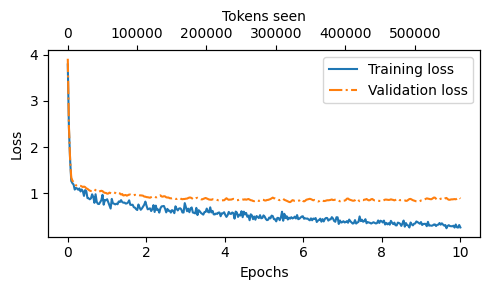

In [22]:
from previous_chapters_FT import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [23]:
from previous_chapters_FT import generate,token_ids_to_text,text_to_token_ids
torch.manual_seed(123)
for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=10,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")



### Instruction:
Analyze the sentimnet in the given sentence. Choose one word from positive,negative, and neutral

### Input:
خلصت شغلي وأنا رايح Starbucks أجيب قهوة .

Correct response:
>> Neutral

Model response:
>> Neutral
-------------------------------------


### Instruction:
Analyze the sentimnet in the given sentence. Choose one word from positive,negative, and neutral

### Input:
خلصت شغلي وقررت to go out for dinner .

Correct response:
>> Neutral

Model response:
>> Neutral
-------------------------------------


### Instruction:
Analyze the sentimnet in the given sentence. Choose one word from positive,negative, and neutral

### Input:
خليت ال car في ال garage عشان كانت الدنيا حر .

Correct response:
>> Neutral

Model response:
>> Neutral
-------------------------------------


In [25]:
print(test_data[0])

{'instruction': 'Analyze the sentimnet in the given sentence. Choose one word from positive,negative, and neutral', 'input': 'خلصت شغلي وأنا رايح Starbucks أجيب قهوة .', 'output': 'Neutral', 'model_response': 'Neutral'}


In [24]:
import torch
import json
from tqdm import tqdm

correct = 0
total = len(test_data)

model.eval()

with torch.no_grad():
    for i, entry in tqdm(enumerate(test_data), total=total):

        input_text = format_input(entry)

        token_ids = generate(
            model=model,
            idx=text_to_token_ids(input_text, tokenizer).to(device),
            max_new_tokens=10,
            context_size=BASE_CONFIG["context_length"],
            eos_id=50256
        )

        generated_text = token_ids_to_text(token_ids, tokenizer)

        response_text = (
            generated_text[len(input_text):]
            .replace("### Response:", "")
            .strip()
        )

        true_response = entry["output"].strip()

        # حفظ رد النموذج
        test_data[i]["model_response"] = response_text

        # مقارنة الردين
        if response_text == true_response:
            correct += 1

accuracy = correct / total

print("Accuracy:", accuracy)

# حفظ النتائج
with open("instruction-data-with-response.json", "w", encoding="utf-8") as file:
    json.dump(test_data, file, indent=4, ensure_ascii=False)

100%|██████████| 80/80 [00:11<00:00,  6.84it/s]

Accuracy: 0.7625


In [26]:
print("Accuracy:", accuracy)

Accuracy: 0.7625
